# Medical Costs — one interaction, two claimants

- Author: [givasile](https://givasile.github.io/)
- Runtime: ~1 min
- Description: the variance ledger on the classic [Medical Cost Personal
  dataset](https://github.com/stedy/Machine-Learning-with-R-datasets) —
  global effects reproduce 84% of a gradient-boosted model, **one split**
  (`bmi`, conditioned on `smoker` and `age`) recovers the rest, and the
  decision sequence shows why `smoker` — the most important feature in the
  model — is *redundant as a split*: `bmi` and `smoker` are two claimants of
  the same interaction pot.

The dataset: 1,338 insurance policyholders with 6 features (`age`, `sex`,
`bmi`, `children`, `smoker`, `region`); the target is the yearly medical
charges billed to each person, in USD. It is the textbook example of a
conditional interaction: **bmi matters a lot — but only for smokers.**

In [1]:
import effector
import numpy as np

np.random.seed(21)

## Load the data

`effector.datasets.MedicalCosts` fetches the CSV, encodes the categorical
columns to integer codes (recording the level names), and does a seeded 80/20
split. Everything stays in **natural units** — so the partition rules below
read directly as `bmi < 30`, `smoker = yes`.

In [2]:
data = effector.datasets.MedicalCosts()

print(f"X_train: {data.x_train.shape}, X_test: {data.x_test.shape}")
print("-" * 62)
for i, name in enumerate(data.feature_names):
    col = data.x_train[:, i]
    cats = data.category_names[i]
    levels = f" levels: {cats}" if cats else ""
    print(f"x_{i} {name:10s} [{data.feature_types[i]:10s}] "
          f"min: {col.min():7.1f}, max: {col.max():7.1f}{levels}")
print("-" * 62)
print(f"target: {data.target_name} ($/year), "
      f"mean: {data.y_train.mean():.0f}, std: {data.y_train.std():.0f}")

X_train: (1070, 6), X_test: (268, 6)
--------------------------------------------------------------
x_0 age        [continuous] min:    18.0, max:    64.0
x_1 sex        [nominal   ] min:     0.0, max:     1.0 levels: ['female', 'male']
x_2 bmi        [continuous] min:    16.8, max:    53.1
x_3 children   [ordinal   ] min:     0.0, max:     5.0
x_4 smoker     [nominal   ] min:     0.0, max:     1.0 levels: ['no', 'yes']
x_5 region     [nominal   ] min:     0.0, max:     3.0 levels: ['northeast', 'northwest', 'southeast', 'southwest']
--------------------------------------------------------------
target: charges ($/year), mean: 13438, std: 12295


## Fit a model

A `HistGradientBoostingRegressor` — fast, deterministic, and strong on this
dataset.

In [3]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score

model = HistGradientBoostingRegressor(random_state=21).fit(data.x_train, data.y_train)
print(f"train R^2 = {r2_score(data.y_train, model.predict(data.x_train)):.3f}")
print(f"test  R^2 = {r2_score(data.y_test, model.predict(data.x_test)):.3f}")

train R^2 = 0.945
test  R^2 = 0.813


## Explain

effector needs a numpy-in / numpy-out callable; for sklearn regressors
`effector.adapters.from_sklearn` builds (and validates) the wrapper. The
schema comes straight off the loader.

In [4]:
model_forward = effector.adapters.from_sklearn(model)
effector.adapters.check(model_forward, data.x_train)

schema = effector.Schema(
    feature_names=data.feature_names,
    feature_types=data.feature_types,
    category_names=data.category_names,
    target_name=data.target_name,
)

## The one-click report

`effector.explain` runs the whole pipeline — fit, rank, search regions,
select the splits worth keeping — and its headline is the **variance
ledger**: how much of the model's variance the global (GAM-style) curves
reproduce, and how much each accepted split adds.

In [5]:
report = effector.explain(
    data=data.x_train,
    model=model_forward,
    schema=schema,
    method="pdp",
    nof_instances=5000,
)
report.show()
report.to_html("report_medical_costs_pdp.html")  # open in browser

[effector] global effects reproduce 84.4% of the model's variance; with subregions, 96.6%

PDP report — target: charges
explained variance: global effects (GAM) 84.4%
  + split bmi (on age, smoker) → 96.6% (+12.1 pts, heter 4497.234→1229.483)
  rejected: smoker (on bmi) — -11.5 pts, redundant (variance already explained)
  rejected: age (on bmi, children, smoker) — +0.4 pts, below the 1.0-pt threshold
------------------------------------------------------------
feature                   importance     heter  #regions
------------------------------------------------------------
smoker                     9741.7124 4202.7570         1
age                        3665.6089 1547.5959         1
bmi                        2669.0218 1229.4831         7
the plotted features carry 91% of the total importance mass


Feature 2 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
bmi 🔹 [id: 0 | heter: 4497.23 | inst: 1070 | w: 1.00]
    smoker = 0.00 🔹 [id: 1 | heter: 1439.97 | ins

## The decision sequence, step by step

`select_regions` is the verb behind the ledger: greedy forward selection over
the candidate partitions, re-measuring every remaining split's marginal gain
each round. It returns a `CalmSequence` — the chain of snapshots from the
pure GAM to the final CALM.

In [6]:
pdp = effector.PDP(data.x_train, model_forward, schema=schema, nof_instances=5000)
chain = pdp.select_regions()
chain.show()

GAM: R2 = 0.844
  + bmi regions (on age, smoker) -> R2 = 0.966 (+12.1 pts)
  x age regions skipped (below_threshold, +0.4 pts)
  x smoker regions skipped (redundant, -11.5 pts)


### Two claimants, one pot

The interesting line in the ledger is the **rejected** one. Solo — measured
directly on top of the GAM — the two candidate splits are nearly equivalent:

- split `bmi` on `smoker`/`age`: **+12.1 pts**
- split `smoker` on `bmi`: **+11.1 pts**

But they describe the *same* interaction. The interaction variance between
`bmi` and `smoker` is one pot, and both splits are claims on it. The greedy
sequence hands the pot to the best claimant (`bmi | smoker, age`); measured
*after* that, the `smoker` split's marginal gain collapses to ~0 and it is
skipped as **redundant**.

Redundant means *already accounted for* — not unimportant. `smoker` remains
by far the strongest main effect in the model (its importance dwarfs
everything else in the report's ranked table); it just has no *additional*
interaction variance to convert once the `bmi` split is in.

In [7]:
# the two-claimants signature, in numbers: solo gain vs sequential marginal
for s in chain.skipped:
    print(f"{s['name']:8s} solo: {s['solo_delta_r2']:+6.1%} | "
          f"after the accepted splits: {s['delta_r2']:+6.1%} [{s['reason']}]")

age      solo:  +0.1% | after the accepted splits:  +0.4% [below_threshold]
smoker   solo: +11.1% | after the accepted splits: -11.5% [redundant]


## Look at the regions

The partition that won the pot, in feature units.

In [8]:
parts = pdp.find_regions("bmi", finder="best")
parts.show()



Feature 2 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
bmi 🔹 [id: 0 | heter: 4497.23 | inst: 1070 | w: 1.00]
    smoker = no 🔹 [id: 1 | heter: 1439.97 | inst: 841 | w: 0.79]
        age < 43.30 🔹 [id: 2 | heter: 1162.94 | inst: 485 | w: 0.45]
        age ≥ 43.30 🔹 [id: 3 | heter: 1423.27 | inst: 356 | w: 0.33]
    smoker = yes 🔹 [id: 4 | heter: 1224.35 | inst: 229 | w: 0.21]
        age < 41.00 🔹 [id: 5 | heter: 1111.57 | inst: 125 | w: 0.12]
        age ≥ 41.00 🔹 [id: 6 | heter: 1018.18 | inst: 104 | w: 0.10]
--------------------------------------------------
Feature 2 - Statistics per tree level:
🌳 Tree Summary:
─────────────────
Level 0🔹heter: 4497.23
    Level 1🔹heter: 1393.82 | 🔻3103.41 (69.01%)
        Level 2🔹heter: 1229.48 | 🔻164.34 (11.79%)




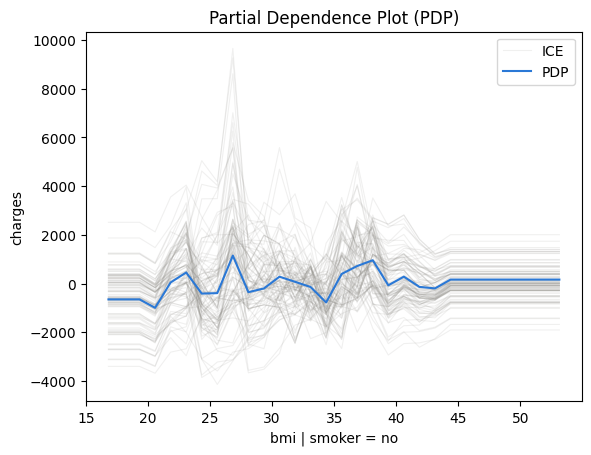

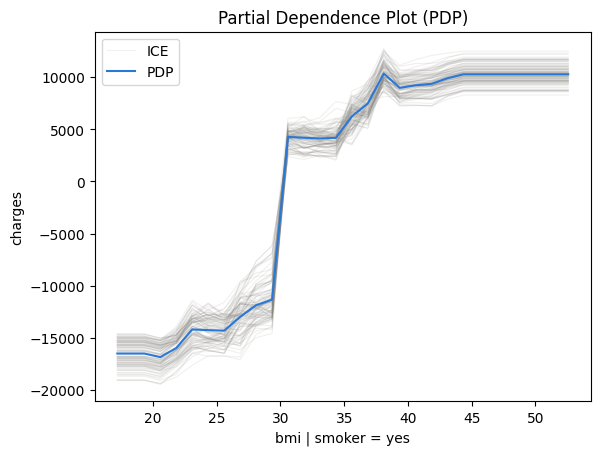

In [9]:
for r in parts:
    if r.level == 1:
        parts.plot(r.idx, centering=True)

The split reads exactly like the domain story: for **non-smokers**, the
`bmi` curve is essentially flat — body mass barely moves the predicted
charges. For **smokers**, charges jump by roughly **$15–20k** past
`bmi ≈ 30` (the clinical obesity threshold). The global `bmi` curve is the
average of these two regimes and represents neither.

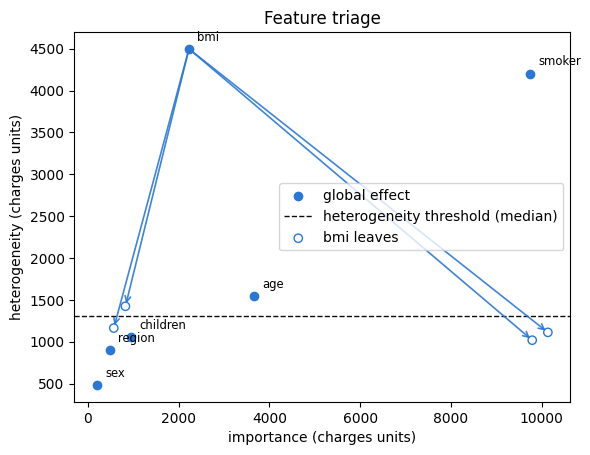

In [10]:
effector.plot_triage(pdp, partitions={"bmi": parts})

On the triage plane the arrows close the loop: the `bmi` leaves move
right and down — more decisive, less heterogeneous — which is what a good
partition does.

## Conclusion

- Global curves explain **84%** of this model; they are a fair summary of
  `age`, `children`, `region` — and of `smoker`'s big main effect.
- The missing 12 pts live in **one** conditional interaction:
  `bmi × smoker`. One split recovers it (**→ 97%**).
- The decision sequence is the honest bookkeeping: `smoker | bmi` is
  *redundant as a split* precisely because `bmi | smoker` already cashed the
  same pot. A report that showed both solo numbers would double-count.

## Cross-method sanity check

The one-liner `effector.explain` with every engine this notebook's model
supports. A gradient-boosted tree is piecewise-constant, so derivative-scale
methods (RHALE, DerPDP) have no meaningful gradients to work with and are out
of scope here; PDP, ALE and SHAP-DP cover the output-scale reads. Where
methods disagree — ranking, accepted splits, R² — that is a property of the
data/model worth a closer look, not an error.


In [11]:
# === cross-method sweep: effector.explain on every applicable engine ======
sweep_reports = {}
for _m in ["pdp", "ale", "shapdp"]:
    _kw = {"nof_instances": 300} if _m == "shapdp" else {"nof_instances": 5000}
    print(f"--- {_m} " + "-" * 50)
    sweep_reports[_m] = effector.explain(
        data.x_train, model_forward, method=_m, schema=schema, **_kw
    )
    sweep_reports[_m].to_html(f"report_medical_costs_{_m}.html")

print()
print(f"{'method':<8} {'ranking (plotted)':<52} {'GAM R2':>8} {'final R2':>9}  splits")
for _m, _r in sweep_reports.items():
    _rank = " > ".join(fr.name for fr in _r.features)
    _ev = _r.explained_variance
    _sp = "; ".join(f"{s['name']} on {s['on']}" for s in _ev["stages"]) or "none"
    print(f"{_m:<8} {_rank:<52} {_ev['gam_r2']:>7.1%} {_ev['regional_r2']:>8.1%}  {_sp}")


--- pdp --------------------------------------------------


[effector] global effects reproduce 84.4% of the model's variance; with subregions, 96.6%


--- ale --------------------------------------------------


[effector] global effects reproduce 84.0% of the model's variance; with subregions, 96.1%


--- shapdp --------------------------------------------------


[effector] global effects reproduce 83.8% of the model's variance; with subregions, 96.7%



method   ranking (plotted)                                      GAM R2  final R2  splits
pdp      smoker > age > bmi                                     84.4%    96.6%  bmi on age, smoker
ale      smoker > age > bmi                                     84.0%    96.1%  bmi on age, smoker
shapdp   smoker > age > bmi                                     83.8%    96.7%  bmi on children, smoker; smoker on bmi
